# Week 7 · Day 3 — Decision Trees & Random Forests

Every model so far drew a mathematical boundary — a line, a curve, a margin. Today's model works completely differently, and more like a **human**. A **decision tree** classifies by asking a series of yes/no questions, exactly like the game *20 Questions* or a troubleshooting flowchart.

Then we discover something powerful: a **whole forest** of trees, voting together, beats any single tree.

**The plan:**
1. How a decision tree thinks — a flowchart of questions.
2. Train one, and *read* the actual questions it learned.
3. The danger: trees overfit. How to control it.
4. From one tree to a forest — the wisdom of crowds.
5. Feature importance — which features actually mattered.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

---
## 1. How a decision tree thinks

A decision tree is just a **flowchart of yes/no questions.** To classify an iris flower, it might ask:

> *"Is the petal short (< 2.5 cm)?"*
> — Yes → it's a **setosa**. Done.
> — No → *"Is the petal narrow (< 1.75 cm)?"*
>   — Yes → probably **versicolor**.
>   — No → probably **virginica**.

Each question **splits** the data into smaller groups; the final answers sit at the ends (the "leaves"). That's the entire model — no equations, no gradient descent, just questions.

**The one idea under the hood:** at each step, the tree picks the question that best **separates** the classes — the one that makes the resulting groups as "pure" (single-class) as possible. It greedily asks the most useful question first. That's all "training a tree" means: *finding the best questions to ask, in the best order.*

The big appeal: unlike logistic regression or SVM, a tree is **fully readable.** You can follow the exact reasoning behind any prediction — which we'll literally see in a moment.

---
## 2. Train a tree — and read its questions

We'll use the Iris flowers dataset (3 species, 4 measurements). Same familiar workflow: load, split, fit.

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# max_depth=3 keeps the tree small enough to read easily
tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)
print("test accuracy:", round(tree.score(X_test, y_test), 3))

test accuracy: 0.933


Now the special part — we can **draw the actual flowchart** the tree learned. `plot_tree` shows every question, from the root down to the leaves.

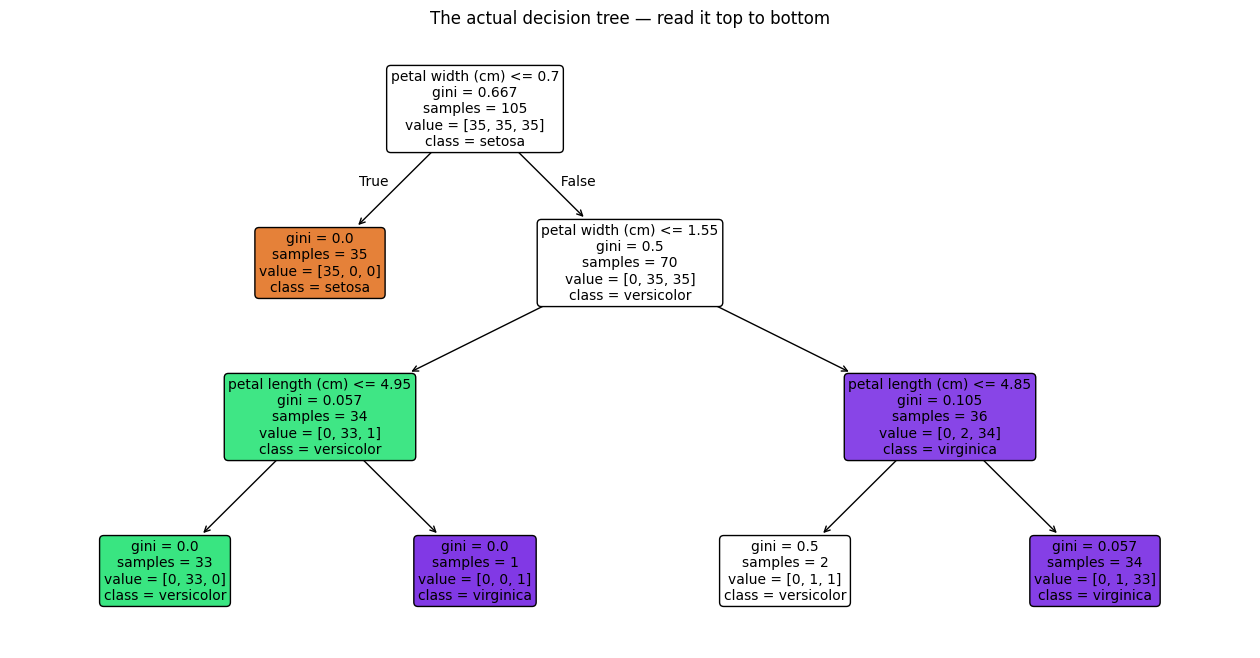

In [3]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(tree,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10)
plt.title("The actual decision tree — read it top to bottom")
plt.show()

**Read it from the top:**
- The **first question** is about petal width — the tree discovered on its own that petal width is the most useful thing to ask about first.
- Follow "True" (yes) branches left, "False" (no) branches right.
- Each box shows the question, how many samples reached it, and which class it leans toward. The **colors** mark the predicted class; a solidly-colored leaf means a pure, confident group.

This is the whole model, completely transparent. For *any* flower, you can trace the exact path of questions that led to its prediction. No other model we've seen is this readable — that **interpretability** is a decision tree's superpower.

---
## 3. The danger: trees love to overfit

We set `max_depth=3` on purpose. Left unlimited, a tree keeps asking questions until every training point sits in its own tiny pure group — it **memorizes the training data**, overfitting badly.

Let's see this clearly on a harder dataset (breast-cancer diagnosis, 30 features). We compare shallow trees with a fully-grown one.

In [4]:
from sklearn.datasets import load_breast_cancer

# a harder dataset where deep-tree overfitting is unmistakable
cancer = load_breast_cancer()
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=1, stratify=cancer.target)

for depth in [2, 3, None]:   # None = grow until perfectly pure
    t = DecisionTreeClassifier(max_depth=depth, random_state=1).fit(Xc_tr, yc_tr)
    train_acc = t.score(Xc_tr, yc_tr)
    test_acc = t.score(Xc_te, yc_te)
    label = f"max_depth={depth}" if depth else "max_depth=None (unlimited)"
    print(f"{label:28s}  train {train_acc:.3f}   test {test_acc:.3f}   gap {train_acc-test_acc:+.3f}")

max_depth=2                   train 0.962   test 0.947   gap +0.015
max_depth=3                   train 0.970   test 0.953   gap +0.017
max_depth=None (unlimited)    train 1.000   test 0.942   gap +0.058


See the pattern from last week again: the shallow trees (depth 2–3) keep a **small** train-test gap, but the **unlimited** tree hits **100% on training** data while its **test accuracy drops** — the widest gap of all. That growing gap is **overfitting**: a deep tree carves the space into jagged little pockets around individual training points, memorizing noise.

**The fix:** limit the tree's growth (`max_depth`, or a minimum number of samples per leaf). A shallower tree is simpler, generalizes better, and stays readable. It's the same complexity dial as always — too deep overfits, too shallow underfits, somewhere in between is right.

But there's a cleverer fix, and it's beautiful...

---
## 4. From one tree to a forest — the wisdom of crowds

A single tree has a weakness: it's **unstable.** Change the training data slightly and it can grow into a completely different shape. One tree is like asking *one* expert — they might be quirky, biased, or just wrong.

The fix is wonderfully simple: **train many trees, each on a random slice of the data, and let them vote.** The majority wins. This is a **Random Forest.**

Why it works — the *wisdom of crowds*: any single tree might overfit or make odd calls, but each does so **differently** (they saw different random slices). When hundreds of slightly-different trees vote, their individual errors tend to **cancel out**, and the correct answer wins the majority. The average of many imperfect experts is far more reliable than any one of them.

Let's prove it. We'll switch to the **Wine** dataset (13 chemical measurements of wines from 3 growers) — a harder problem where the forest's advantage is clear.

In [5]:
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

wine = load_wine()

# cross-validation = average over several train/test splits, a fairer score than one split
single_tree = DecisionTreeClassifier(random_state=1)
forest = RandomForestClassifier(n_estimators=100, random_state=1)   # 100 trees

tree_score = cross_val_score(single_tree, wine.data, wine.target, cv=5).mean()
forest_score = cross_val_score(forest, wine.data, wine.target, cv=5).mean()

print(f"single decision tree : {tree_score:.1%}")
print(f"random forest (100 trees): {forest_score:.1%}")
print(f"\nimprovement from the forest: {forest_score - tree_score:+.1%}")

single decision tree : 88.8%
random forest (100 trees): 97.8%

improvement from the forest: +9.0%


The forest jumps well ahead of the single tree — a large gain for almost no extra effort, just by letting many trees vote instead of trusting one. The API is identical (`.fit()`, `.predict()`); `n_estimators=100` simply means "grow 100 trees."

*(We used **cross-validation** here — averaging accuracy over 5 different train/test splits instead of trusting one lucky split. It's a fairer, more honest score, and worth knowing.)*

---
## 5. Feature importance — which measurements mattered?

A random forest can tell us **which features it relied on most** to make decisions. This is genuinely useful in real projects — it answers *"what actually drives this prediction?"*

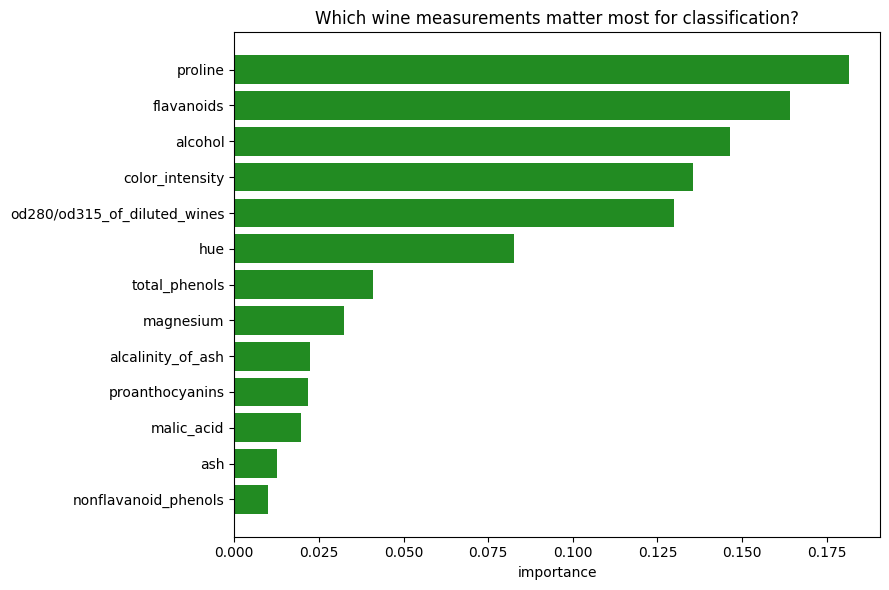

In [6]:
forest = RandomForestClassifier(n_estimators=100, random_state=1)
forest.fit(wine.data, wine.target)

# each feature gets an importance score (they sum to 1)
importances = forest.feature_importances_

# sort and plot them
order = np.argsort(importances)
plt.figure(figsize=(9, 6))
plt.barh(np.array(wine.feature_names)[order], importances[order], color="forestgreen")
plt.xlabel("importance")
plt.title("Which wine measurements matter most for classification?")
plt.tight_layout()
plt.show()

In [7]:
# print the top 3 in words
top3 = np.argsort(importances)[::-1][:3]
print("The 3 most important measurements:")
for rank, i in enumerate(top3, 1):
    print(f"  {rank}. {wine.feature_names[i]}  (importance {importances[i]:.3f})")

The 3 most important measurements:
  1. proline  (importance 0.182)
  2. flavanoids  (importance 0.164)
  3. alcohol  (importance 0.146)


The forest tells us exactly which chemical measurements best distinguish the wines — the long bars are the features doing the heavy lifting, the short bars barely matter. In a real project this is gold: it tells you what to focus on, and sometimes lets you drop the useless features entirely.

*(Logistic regression and SVM don't hand you this so easily — another reason trees and forests are beloved in practice.)*

---
## 6. Evaluate — the same tools as always

A forest is judged with the identical toolkit as every classifier — confusion matrix, precision, recall, F1.

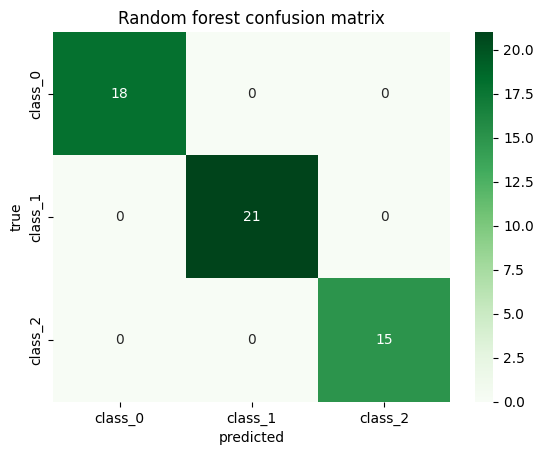

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Xtr, Xte, ytr, yte = train_test_split(wine.data, wine.target, test_size=0.3,
                                      random_state=1, stratify=wine.target)
forest = RandomForestClassifier(n_estimators=100, random_state=1).fit(Xtr, ytr)
pred = forest.predict(Xte)

cm = confusion_matrix(yte, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Random forest confusion matrix")
plt.show()

print(classification_report(yte, pred, target_names=wine.target_names))

---
## Summary

- A **decision tree** classifies by asking a sequence of **yes/no questions** — a readable flowchart. It picks the most-separating question at each step.
- Trees are the most **interpretable** model in the course: `plot_tree` shows the exact reasoning behind every prediction.
- Trees **overfit easily** — an unlimited tree memorizes the training data. Control it with `max_depth` (the familiar complexity dial).
- A **Random Forest** trains many trees on random slices of data and lets them **vote**. The wisdom of crowds: individual errors cancel out, so the forest beats any single tree — usually a big accuracy gain for almost no extra effort.
- **Feature importance** (`feature_importances_`) reveals which features drove the decisions — genuinely useful for understanding a problem.
- Forests are evaluated with the **same** confusion-matrix / precision / recall / F1 toolkit as every classifier.

Next time: **Naive Bayes** — a fast, elegant classifier built entirely from probability, and famously good at text.